### Main libraries and variables

In [3]:
# !pip install torch_geometric torcheval #ax ax-platform # Colab

In [4]:
import torch
import numpy as np
import pandas as pd
import os
import json 
from os.path import dirname
pd.set_option("display.max_columns", None)

DATASET         = f"sp2020"

ROOT_PATH       = f"{dirname(os.getcwd())}/ISG"
# ROOT_PATH       = f"drive/MyDrive/Thesis" 
PROCESSED_PATH  = f"{ROOT_PATH}/data/datasets/processed/{DATASET}"
GRAPHS_PATH     = f"{ROOT_PATH}/data/datasets/graphs/{DATASET}"
MODEL_PATH      = f"{ROOT_PATH}/data/datasets/models/{DATASET}"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
PATIENCE = 10
NUM_EPOCHS = 200
TOT_TRIALS = 20

In [6]:
with open(f"{ROOT_PATH}/data/dataset_features.json", 'r') as file:
    dataset_info = json.load(file)[DATASET]

categorical_columns = dataset_info["categorical"]
real_value_columns = dataset_info["numerical"]

tab_all = pd.read_csv(f"{PROCESSED_PATH}/{DATASET}_processed_all.csv")

list_unique = {k : list(tab_all[k].unique()) for k in categorical_columns}

idx_to_activity = {i: name for i, name in enumerate(list_unique["Activity"])} # Index-activity map

In [7]:
outputcat  = {k: len(list_unique[k]) for k in categorical_columns if k in ("Activity", "org:resource")}
outputreal = [k for k in real_value_columns if k == "time:timestamp"]

# +1 adds the end node
outputcat["Activity"] = outputcat["Activity"] + 1

In [8]:
import random

torch.manual_seed(0)
torch.cuda.manual_seed(0)
random.seed(0)
np.random.seed(0)


from torch_geometric.data.hetero_data import HeteroData

torch.serialization.add_safe_globals([HeteroData])

from torch_geometric.loader import DataLoader

### Loading graphs

In [9]:
X_TRAIN = torch.load(f"{GRAPHS_PATH}/train_set.pt", weights_only=False)
X_VALID = torch.load(f"{GRAPHS_PATH}/validation_set.pt", weights_only=False)
X_TEST  = torch.load(f"{GRAPHS_PATH}/test_set.pt", weights_only=False)

In [10]:
edge_types = set()
node_types = set()
for i in range(len(X_TRAIN)):
    n, edge_type = X_TRAIN[i].metadata()
    for x in n:
        node_types.add(x)
    for x in edge_type:
        edge_types.add(x)
for i in range(len(X_VALID)):
    n, edge_type = X_VALID[i].metadata()
    for x in n:
        node_types.add(x)
    for x in edge_type:
        edge_types.add(x)
for i in range(len(X_TEST)):
    n, edge_type = X_TEST[i][0].metadata()
    for x in n:
        node_types.add(x)
    for x in edge_type:
        edge_types.add(x)

NODE_TYPES = list(node_types)
EDGE_TYPES = list(edge_types)

In [11]:
# todo ADD END NODE?

### Hyperopt

In [12]:
from ax.service.managed_loop import optimize
from torch_geometric.nn import (
    HeteroConv,
    GATv2Conv,global_mean_pool
)
from torch.nn import (
    ModuleList,
    Module,
    Linear,
    ModuleDict,
  )
from typing_extensions import Self

from torcheval.metrics.functional import multiclass_accuracy  
import torch.nn as nn
from copy import deepcopy
from tqdm.notebook import tqdm
from time import time

from torch.nn.functional import l1_loss
from torcheval.metrics.functional import multiclass_f1_score 

In [13]:
class HGNN(Module):

    def __init__(self, output_cat, output_real, nodes_relations, parameters) -> Self:
        super().__init__()

        # Hyperparameters
        hid = parameters["hid"]
        layers = parameters["layers"]
        aggregation = parameters["aggregation"]

        # Set model outputs
        self.output_cat = output_cat
        self.output_real = output_real

        # Create convolutional layers
        self.convs = ModuleList()
        for _ in range(layers):
            # For each layer create a convolutional step (GATv2Conv) for each relationship type
            conv = HeteroConv(
                {
                    relation: (
                        GATv2Conv(
                            (-1, -1), hid, 1, False, add_self_loops=False, residual=False
                        )
                    )
                    for relation in nodes_relations
                },
                aggr=aggregation,
            )

            self.convs.append(conv)

        self.FC = ModuleDict()

        # Create a linear layer based on the output type
        for k in output_cat:
            self.FC[k] = Linear(hid, output_cat[k]) # Logits
        for k in output_real:
            self.FC[k] = Linear(hid, 1)             # Number


    def forward(self, batch):
        """
        Each convolutional layer:
        Takes the current node features (x_dict, a dict of node_type → tensor)
        Passes messages along edges (edge_index_dict, a dict of relation → edge list)
        Updates every node's embedding based on its neighbors
        Applies ReLU activation to introduce non-linearity
        """
        x_dict = batch.x_dict  # local copy

        for conv in self.convs:
            x_dict = conv(x_dict, batch.edge_index_dict)
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        output = {}

        for k in self.output_cat:
            output[k] = global_mean_pool(x_dict[k], batch[k].batch)
            output[k] = self.FC[k](output[k])
        for k in self.output_real:
            output[k] = global_mean_pool(x_dict[k], batch[k].batch)
            output[k] = self.FC[k](output[k]).reshape(1, -1)[0]

        return output

In [14]:
from tqdm.notebook import tqdm

# Training

In [16]:
def train_hgnn(config, output_cat, output_real):
    print(config)

    # Instantiate the HGNN
    net = HGNN(
        parameters=config,
        output_cat=output_cat,
        output_real=output_real,
        nodes_relations=EDGE_TYPES,
    )
    net = net.to(device)

    # Asssign loss functions to the categories
    losses = {}
    for k in output_cat:
        losses[k] = nn.CrossEntropyLoss()
    for k in output_real:
        losses[k] = nn.L1Loss()

    # Data loading (automatical batches splitting!!)
    # In this case the DataLoader takes a batch of separate graph objects and merges them into one big disconnected graph.
    train_loader = DataLoader(X_TRAIN, batch_size=config["batch_size"], 
                          shuffle=True, num_workers=8, pin_memory=True)
    valid_loader = DataLoader(X_VALID, batch_size=config["batch_size"], 
                          shuffle=True, num_workers=8, pin_memory=True)
    
    # Adam optimizer + scheduler
    optimizer = torch.optim.Adam(
        net.parameters(), lr=config["lr"]
    )
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,mode="min", patience=int(PATIENCE/2)
    )
    
    # Trackers
    best_model = None
    best_loss = 0
    best_f1 = 0
    patience = PATIENCE
    pat_count = 0

    torch.cuda.empty_cache()
    training_times = []
    
    
    # TRAINING
    for epoch in tqdm(range(0, NUM_EPOCHS)):
        net.train()

        # == Inner training step ==
        for _, x in enumerate(train_loader):
            x = x.to(device)
            labels = x.y
            optimizer.zero_grad()
            
            # Forward pass!!
            outputs = net(x)

            # Compute each loss individually then total it
            losses_step = {k: losses[k](outputs[k], labels[k]) for k in losses}
            total_loss = 0
            for k in losses_step:
                total_loss += losses_step[k]

            # Compute gradients via backpropagation
            total_loss.backward()
            # Update parameters 
            optimizer.step()

        
        # Setup
        running_total_loss = []
        predictions_categorical = {k: [] for k in output_cat}
        target_categorical = {k: [] for k in output_cat}
        avg_MAE = {k : [] for k in output_real}
        prediction_numerical = {k: [] for k in output_real}
        target_numerical = {k: [] for k in output_real}
        

        # == Validation step ==
        net.eval()
        with torch.no_grad():
            for i, x in enumerate(valid_loader):
                x = x.to(device)
                labels = x.y
                
                # Forward pass
                outputs = net(x)

                # Compute loss
                losses_step = {k: losses[k](outputs[k], labels[k]) for k in losses}
                running_total_loss.append(sum(list(losses_step.values())))
            
                # INDENTING IT FORWARD BUT I DON'T KNOW IF THIS IS CORRECT
                for k in output_cat:
                    predictions_categorical[k].append(
                            torch.argmax(torch.softmax(outputs[k], dim=1), 1)
                    )
                    target_categorical[k].append(labels[k])
                
                
                for k in output_real:
                    prediction_numerical[k].append(
                        outputs[k]
                    )
                    target_numerical[k].append(
                        labels[k]
                    )

        
        # Mean loss in validation step, used to handle learning rate
        val_loss = sum(running_total_loss) / len(running_total_loss)
        lr_scheduler.step(val_loss)
        
        """
        torch.cat concatenates a list of tensors along dimension 0. 
        The pattern here is: during the loop you append per-batch tensors to a list, 
        then after the loop you join them into one big tensor covering the whole 
        validation set — standard practice in PyTorch evaluation. 
        """
        for k in predictions_categorical:
            predictions_categorical[k] = torch.cat(predictions_categorical[k])
            target_categorical[k] = torch.cat(target_categorical[k])
                
        for k in prediction_numerical:
            prediction_numerical[k] = torch.cat(prediction_numerical[k])
            target_numerical[k] = torch.cat(target_numerical[k])
    
        
       
        # == Metrics computation ==

        # averages the F1 score of each class equally,        
        macro_f1s = {
            k : multiclass_f1_score(
                predictions_categorical[k],
                target_categorical[k].squeeze(),
                num_classes=output_cat[k],
                average='macro'
            ) 
            for k in output_cat
        }
        f1_activity = macro_f1s["Activity"]
        
        
        # fraction of correct predictions
        accuracy = {
                k: multiclass_accuracy(
                    predictions_categorical[k],
                    target_categorical[k].squeeze(),
                    num_classes=output_cat[k],
                )
                for k in output_cat
            }
        
        # MAE recomputation
        MAE = {
            k: l1_loss(prediction_numerical[k], target_numerical[k]).item()
            for k in output_real
        }


        # == Metrics check ==
        if epoch == 0:
            best_model = deepcopy(net)
            best_loss = val_loss
            best_f1 = f1_activity
            print("/"*10)
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
            print("Acc", accuracy)
            print("F1s", macro_f1s)
            print("MAE", MAE)
            print(f"Patience {pat_count}/{patience}, val loss {val_loss} current_lr {lr_scheduler.get_last_lr()}, curr_best_activity_F1 {best_f1}")
        else:
            
            if val_loss < best_loss:
                best_loss = val_loss
                best_model = deepcopy(net)
                pat_count = -1
            if best_f1 < f1_activity:
                best_f1 = f1_activity

            print("/"*10)
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
            print("Acc", accuracy)
            print("F1s", macro_f1s)
            print("MAE", MAE)
            print(f"Patience {pat_count}/{patience}, val loss {val_loss} current_lr {lr_scheduler.get_last_lr()}, curr_best_activity_F1 {best_f1}")
            if pat_count == patience:
                return ({"valid_loss" : best_loss.item()} , best_model)
        pat_count += 1
    print("Acc", accuracy)
    print("F1s", macro_f1s)
    print("MAE", MAE)
    print(f"Patience {pat_count}/{patience}, val loss {val_loss} current_lr {lr_scheduler.get_last_lr()}, curr_best_activity_F1 {best_f1}")
    return ({"valid_loss" : best_loss.item()} , best_model)
   

In [15]:
import logging

logging.getLogger("root").setLevel(logging.ERROR)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

(stop execution here if you already got the best parameters)

In [16]:
def train_evaluate(config):
    res, _ = train_hgnn(config, output_cat=outputcat, output_real=outputreal)
    return res
    """
    For graph data specifically (PyTorch Geometric), the DataLoader does something extra:
    it takes a batch of separate graph objects and merges them into one big disconnected graph.
    """

In [ ]:
# Hyperparameters optimization (Ax)
best_parameters, values, experiment, model = optimize(
    parameters=[
        {"name": "hid", "type": "choice", "values": [128, 256, 512], "value_type": "int", "is_ordered": True, "sort_values": False},
        {"name": "batch_size", "type": "choice", "values": [256, 512, 1024], "value_type": "int", "is_ordered": True, "sort_values": False},
        {"name": "layers", "type": "choice", "values": [2,4], "value_type": "int", "is_ordered" : True, "sort_values":False},
        {"name": "lr", "type": "range", "bounds": [1e-4, 1e-2], "value_type": "float", "log_scale": True},
        {"name": "aggregation", "type" : "choice", "values" :["sum", "mean", "max"], "value_type" : "str"},
    ],
  
    evaluation_function=train_evaluate,
    objective_name='valid_loss',
    arms_per_trial=1,
    minimize = True,
    random_seed = 123,
    total_trials = TOT_TRIALS
)

print(best_parameters)
means, covariances = values
print(means)
print(experiment)

""" To cut on time
best_parameters = {
    "hid": 128,
    "layers": 2,
    "lr": 1e-3,
    "aggregation": "mean",
    "batch_size": 128,
}
"""

In [18]:
from ax.service.utils.report_utils import exp_to_df

results = exp_to_df(experiment)

[WARNING 06-27 13:11:50] ax.service.utils.report_utils: Column reason missing for all trials. Not appending column.


In [19]:
results.sort_values(by="valid_loss")

,trial_index,arm_name,trial_status,generation_method,valid_loss,hid,batch_size,layers,lr,aggregation
17,17,17_0,COMPLETED,BoTorch,0.611860,512,512,4,0.000178,max
12,12,12_0,COMPLETED,BoTorch,0.612244,512,512,4,0.000163,max
15,15,15_0,COMPLETED,BoTorch,0.612693,512,256,4,0.000166,max
6,6,6_0,COMPLETED,Sobol,0.616447,256,512,4,0.000138,max
1,1,1_0,COMPLETED,Sobol,0.616757,512,256,4,0.000263,max
11,11,11_0,COMPLETED,BoTorch,0.617467,256,256,4,0.000100,max
5,5,5_0,COMPLETED,Sobol,0.619169,512,256,2,0.001192,sum
16,16,16_0,COMPLETED,BoTorch,0.619775,512,1024,4,0.000180,max
14,14,14_0,COMPLETED,BoTorch,0.619977,512,512,4,0.000100,max
13,13,13_0,COMPLETED,BoTorch,0.620777,512,512,4,0.000100,sum


In [20]:
results = results.sort_values(by="valid_loss")

In [21]:
if not os.path.isdir(f"{ROOT_PATH}/results/{DATASET}"):
    os.mkdir(f"{ROOT_PATH}/results/{DATASET}")

In [22]:
results.to_csv(f"{ROOT_PATH}/results/{DATASET}/hyp_params_search.csv", sep=",", index=False)

In [ ]:
with open(f"{ROOT_PATH}/results/{DATASET}/best_parameters.csv", "w") as f:
    json.dump(best_parameters, f, indent=4)

# Test 

In [ ]:
import sklearn.preprocessing

# The one in dp
def get_one_hot_encoder(dataset, key):
    datas = dataset[key].unique()                   # Get all the values a key could have
    if key == "Activity":                           # Add the END node
        datas = np.union1d(datas, ["END"])         
    datas = datas.astype(np.str_)                   # Make everything a string
    datas = datas.reshape([len(datas), 1])          # Add a dimension
    onehot = sklearn.preprocessing.OneHotEncoder()  # Learn and return
    onehot.fit(datas)
    return onehot

def to_onehot(logits, n_classes):
    idx = torch.argmax(logits, dim=1).item() 
    oh = torch.zeros(1, n_classes)
    oh[0, idx] = 1.0
    return oh

ONE_HOT_ENCODERS = {k: get_one_hot_encoder(tab_all, k) for k in categorical_columns}
print(ONE_HOT_ENCODERS["Activity"].categories_[0].tolist())
END_IDX = int(ONE_HOT_ENCODERS["Activity"].transform([["END"]]).argmax())
print(f"END class index: {END_IDX}")

['Approved', 'Completed', 'Creation', 'DeviceReceived', 'END', 'FreeticketComp', 'FreeticketCust', 'InDelivery', 'Letter', 'NoteHotline', 'NoteWorkshop', 'StatusRequest', 'StockEntry', 'Transmission']
END class index: 4


In [ ]:
# The one in dp
def compute_edges_indexs(node_features, prefix_len):
    """Stessa funzione del notebook 1 — copiala qui"""
    res = {}
    keys = node_features.keys()
    indexes = [[i, i + 1] for i in range(prefix_len - 1)]
    for k in keys:
        if len(node_features[k]) != 1:
            if k == "Activity":
                res[(k, "followed_by", k)] = indexes
                for k2 in keys:
                    if k2 != k:
                        if len(node_features[k2]) == 1:
                            res[(k, "related_to", k2)] = [[i, 0] for i in range(prefix_len)]
                        else:
                            res[(k, "related_to", k2)] = [[i, i] for i in range(prefix_len)]
            else:
                res[(k, "related_to", k)] = indexes
    return res

In [ ]:
from torch_geometric.transforms import ToUndirected
def append_predicted_event(g, out, outputcat, outputreal):
    new_g = HeteroData()

    # --- Nodi ---
    for node_type in g.node_types:
        existing = g[node_type].x.detach().cpu()

        if node_type == "Activity":
            # Sempre un nuovo nodo
            new_feat = to_onehot(out[node_type], outputcat[node_type])
            new_g[node_type].x = torch.cat([existing, new_feat], dim=0)

        elif existing.shape[0] == 1:
            # Nodo statico: rimane invariato, non si tocca
            new_g[node_type].x = existing

        elif node_type in outputcat:
            # Dinamico categorico: appendi sempre (no dedup, coerente col training)
            new_feat = to_onehot(out[node_type], outputcat[node_type])
            new_g[node_type].x = torch.cat([existing, new_feat], dim=0)

        elif node_type in outputreal:
            # Dinamico numerico: appendi
            new_feat = out[node_type].reshape(1, 1).detach().cpu()
            new_g[node_type].x = torch.cat([existing, new_feat], dim=0)

        else:
            # Tipo non gestito: copia invariato
            new_g[node_type].x = existing

    # --- Edge: ricostruzione da zero (evita bug rev edges) ---
    prefix_len = new_g["Activity"].x.shape[0]
    node_features_proxy = {nt: new_g[nt].x for nt in new_g.node_types}
    edges = compute_edges_indexs(node_features_proxy, prefix_len)

    for rel, edge_list in edges.items():
        src_nodes = [pair[0] for pair in edge_list]
        dst_nodes = [pair[1] for pair in edge_list]
        new_g[rel].edge_index = torch.tensor(
            [src_nodes, dst_nodes], dtype=torch.long
        )

    new_g = ToUndirected()(new_g)
    return new_g

In [1]:
from data.drawer import drawer
from Levenshtein import distance

def seq_levenshtein(seq1, seq2):
    """Levenshtein distance su sequenze di interi."""
    s1 = "".join(chr(i + 256) for i in seq1)
    s2 = "".join(chr(i + 256) for i in seq2)
    return distance(s1, s2)

In [ ]:
from torch_geometric.data import Batch

def autoregressive_inference(net, output_cat, output_real, max_steps=100):
    """
    Per ogni traccia nel test set:
      - parte dal prefisso di 2 eventi
      - predice il prossimo evento
      - lo appende al grafo
      - ripete finché predice END o raggiunge max_steps
      - confronta con il ground truth
    """
    net.eval()
    all_predicted_act = []
    all_ground_truth_act = []
    lev_act = []
    lev_res = []
    mae_stepbystep = []
    mae_remaining = []

    with torch.no_grad():
        for graph, ground_truth in tqdm(X_TEST):
            current_graph = graph.clone()
            predicted_activities = []
            predicted_resources  = []
            predicted_timestamps = []

            for _ in range(max_steps):
                batched = Batch.from_data_list([current_graph]).to(device)
                output = net(batched)

                pred_act = torch.argmax(output["Activity"], dim=-1).item()
                pred_res = torch.argmax(output["org:resource"], dim=-1).item()
                pred_time = output["time:timestamp"].item()

                predicted_activities.append(pred_act)
                predicted_resources.append(pred_res)
                predicted_timestamps.append(pred_time)

                if pred_act == END_IDX:
                    break

                output_cpu = {k: v.cpu() for k, v in output.items()}
                current_graph = append_predicted_event(
                    current_graph, output_cpu, output_cat, output_real
                )

            gt_activities = [torch.argmax(v).item() for v in ground_truth["Activity"]][2:]
            gt_resources = (
                [torch.argmax(ground_truth["org:resource"][i]).item() for i in range(2, len(ground_truth["org:resource"]))] 
                if "org:resource" in ground_truth and len(ground_truth["org:resource"]) > 1 
                else [torch.argmax(ground_truth["org:resource"][0]).item()] * len(gt_activities) 
                if "org:resource" in ground_truth
                else []
            )
            gt_timestamps = (
                [ground_truth["time:timestamp"][i].item() for i in range(2, len(ground_truth["time:timestamp"]))] 
                if "time:timestamp" in ground_truth 
                else []
            )

            # Metrics
            lev_act.append(seq_levenshtein(predicted_activities, gt_activities))
            if gt_resources:
                lev_res.append(seq_levenshtein(predicted_resources, gt_resources))

            if gt_timestamps:
                min_len = min(len(predicted_timestamps), len(gt_timestamps))
                mae_sbs = sum(abs(predicted_timestamps[i] - gt_timestamps[i]) for i in range(min_len)) / min_len
                mae_stepbystep.append(mae_sbs)

                mae_remaining.append(
                    abs(sum(predicted_timestamps) - sum(gt_timestamps))
                )

            all_predicted_act.append(predicted_activities)
            all_ground_truth_act.append(gt_activities)
        
    n = len(X_TEST)
    res = {
        "n_traces":              n,
        "lev_act_mean":          sum(lev_act) / n,
        "lev_act_std":           float(torch.tensor(lev_act, dtype=torch.float).std()),
        "lev_res_mean":          sum(lev_res) / len(lev_res) if lev_res else None,
        "lev_res_std":           float(torch.tensor(lev_res, dtype=torch.float).std()) if lev_res else None,
        "mae_stepbystep_mean":   sum(mae_stepbystep) / len(mae_stepbystep) if mae_stepbystep else None,
        "mae_stepbystep_std":    float(torch.tensor(mae_stepbystep, dtype=torch.float).std()) if mae_stepbystep else None,
        "mae_remaining_mean":    sum(mae_remaining) / len(mae_remaining) if mae_remaining else None,
        "mae_remaining_std":     float(torch.tensor(mae_remaining, dtype=torch.float).std()) if mae_remaining else None,
    }


    return res

## Test on 10 models

In [ ]:
import pandas

def create_df(results):
    res = {}
    for k in results[0]:
        res[k] = [x[k] for x in results]
    print(res)
    res = pandas.DataFrame(data=res)
    
    return res, res.mean(), res.std()
        

In [25]:
def test_multi(config, outputcat, outputreal, num_runs=10):

    res = []

    save_path = f"{ROOT_PATH}/{DATASET}"

    for i in range(num_runs):

        print(f"Run {i}")

        _,net = train_hgnn(
                config,
                outputcat,
                outputreal,
            )

        res.append(
            test_hgnn(
                net,
                outputcat,
                outputreal,
            )
        )

        print("RES:")
        print(res[-1])


    results_table, means, stds = create_df(res)

    results_table.to_csv(f"{save_path}/results.csv", sep=",", index=False)

    pd.DataFrame(data={"mean" : means, "std" : stds}).to_csv(f"{save_path}mean_and_stds.csv", sep=",")

    print(pd.DataFrame(data={"mean" : means, "std" : stds}))



    return res

In [ ]:
# test_multi(best_parameters, outputcat, outputreal, 10)

_,net = train_hgnn(best_parameters,outputcat,outputreal)

In [27]:
torch.save(net.state_dict(), f"{MODEL_PATH}/model.pt")

In [ ]:
breakpoint()

# Scraps area

In [ ]:
with open(f"{ROOT_PATH}/results/{DATASET}/best_parameters.csv", "r") as f:
    best_parameters = json.load(f)

# Instantiate the HGNN
net = HGNN(
    parameters=best_parameters,
    output_cat=outputcat,
    output_real=outputreal,
    nodes_relations=EDGE_TYPES,
)
net.load_state_dict(torch.load(f"{MODEL_PATH}/model.pt", map_location=device, weights_only=False))
net = net.to(device)
net.eval()

HGNN(
  (convs): ModuleList(
    (0-3): 4 x HeteroConv(num_relations=12)
  )
  (FC): ModuleDict(
    (Activity): Linear(in_features=512, out_features=14, bias=True)
    (org:resource): Linear(in_features=512, out_features=12, bias=True)
    (time:timestamp): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [120]:
from data.drawer import drawer
from Levenshtein import distance

def seq_levenshtein(seq1, seq2):
    """Levenshtein distance su sequenze di interi."""
    s1 = "".join(chr(i + 256) for i in seq1)
    s2 = "".join(chr(i + 256) for i in seq2)
    return distance(s1, s2)


def inference_single(net, g, t, max_steps=100):
    net.eval()
    current_graph = g.clone()

    predicted_activities = []
    predicted_resources  = []
    predicted_timestamps = []

    with torch.no_grad():
        for step in range(max_steps):
            batched = Batch.from_data_list([current_graph]).to(device)
            output = net(batched)

            pred_act = torch.argmax(output["Activity"], dim=-1).item()
            pred_res = torch.argmax(output["org:resource"], dim=-1).item()
            pred_time = output["time:timestamp"].item()
            predicted_activities.append(pred_act)
            predicted_resources.append(pred_res)
            predicted_timestamps.append(pred_time)

            pred_str = ONE_HOT_ENCODERS["Activity"].categories_[0][pred_act]
            print(f"Step {step+1}: {pred_str} (class {pred_act}) (res {pred_res}) (time {pred_time})")

            if pred_act == END_IDX:
                print("→ END predicted, stopping")
                break

            output_cpu = {k: v.cpu() for k, v in output.items()}
            current_graph = append_predicted_event(
                current_graph, output_cpu, outputcat, outputreal
            )
        else:
            print(f"→ max_steps ({max_steps}) reached without END")

    # Ground truth — skip i primi 2 eventi (già nel prefisso)
    act_cats     = ONE_HOT_ENCODERS["Activity"].categories_[0]
    gt_activities = [torch.argmax(v).item() for v in t["Activity"]][2:]
    gt_timestamps = [t["time:timestamp"][i].item()
                     for i in range(2, len(t["time:timestamp"]))] if "time:timestamp" in t else []
    if "org:resource" in t: # solving compression problem
        if len(t["org:resource"]) > 1:
            # Normal case: 1 resource per event. Skip the 2 prefix events.
            gt_resources = [
                torch.argmax(t["org:resource"][i]).item() 
                for i in range(2, len(t["org:resource"]))
            ]
        else:
            # Optimized case: length is 1. Get that single resource and repeat it.
            single_res = torch.argmax(t["org:resource"][0]).item()
            gt_resources = [single_res] * len(gt_activities)
    else:
        gt_resources = []

    gt_strings   = [act_cats[i] for i in gt_activities]
    pred_strings = [act_cats[i] for i in predicted_activities]

    print("\n--- Ground Truth (suffix) ---")
    for i, (idx, name) in enumerate(zip(gt_activities, gt_strings)):
        print(f"  {i+1}: {name} (class {idx})")

    print("\n--- Predicted ---")
    for i, (idx, name) in enumerate(zip(predicted_activities, pred_strings)):
        print(f"  {i+1}: {name} (class {idx})")

    print(f"\nGT length:   {len(gt_activities)}")
    print(f"Pred length: {len(predicted_activities)}")

    # --- Metriche ---
    print(f"\nLevenshtein (Activity):  {seq_levenshtein(predicted_activities, gt_activities)}")
    print(f"Levenshtein (Resource):  {seq_levenshtein(predicted_resources, gt_resources)}")
    min_len = min(len(predicted_timestamps), len(gt_timestamps))
    mae = sum(abs(predicted_timestamps[i] - gt_timestamps[i]) for i in range(min_len)) / min_len
    print(f"MAE (Timestamp):         {mae:.4f}")

    drawer(current_graph)

    return predicted_activities, gt_activities


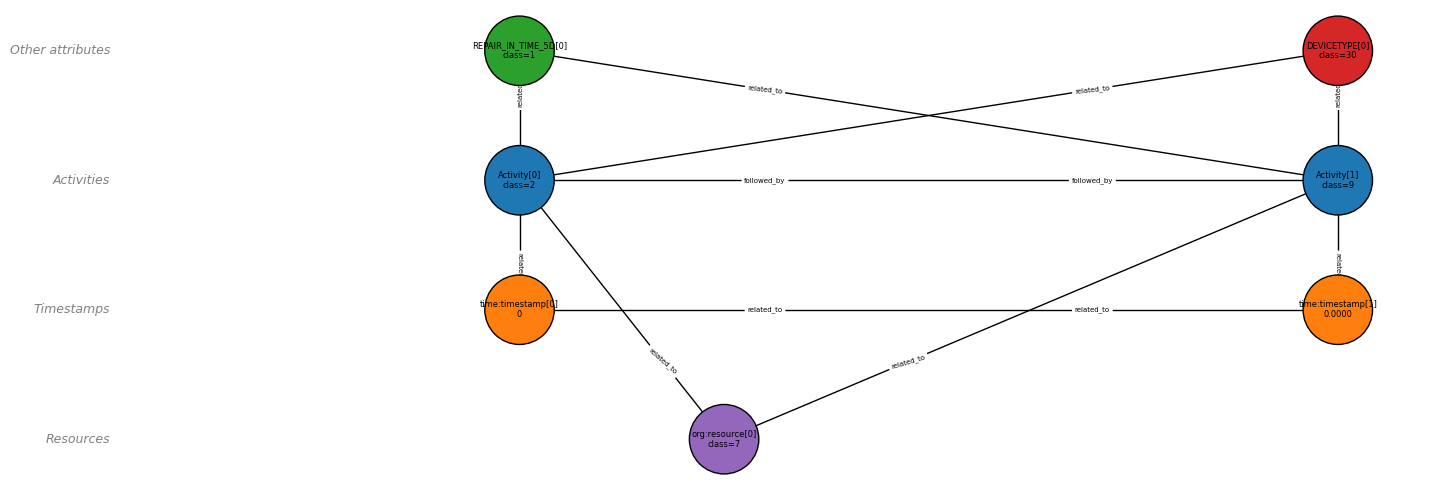

In [119]:
g,t = X_TEST[5]
drawer(g)

Step 1: DeviceReceived (class 3) (res 7) (time 0.002636956050992012)
Step 2: InDelivery (class 7) (res 7) (time 0.002658883109688759)
Step 3: Completed (class 1) (res 7) (time 0.004819249734282494)
Step 4: END (class 4) (res 7) (time 0.004475347697734833)
→ END predicted, stopping

--- Ground Truth (suffix) ---
  1: DeviceReceived (class 3)
  2: InDelivery (class 7)
  3: Completed (class 1)
  4: END (class 4)

--- Predicted ---
  1: DeviceReceived (class 3)
  2: InDelivery (class 7)
  3: Completed (class 1)
  4: END (class 4)

GT length:   4
Pred length: 4

Levenshtein (Activity):  0
Levenshtein (Resource):  0
MAE (Timestamp):         0.0012


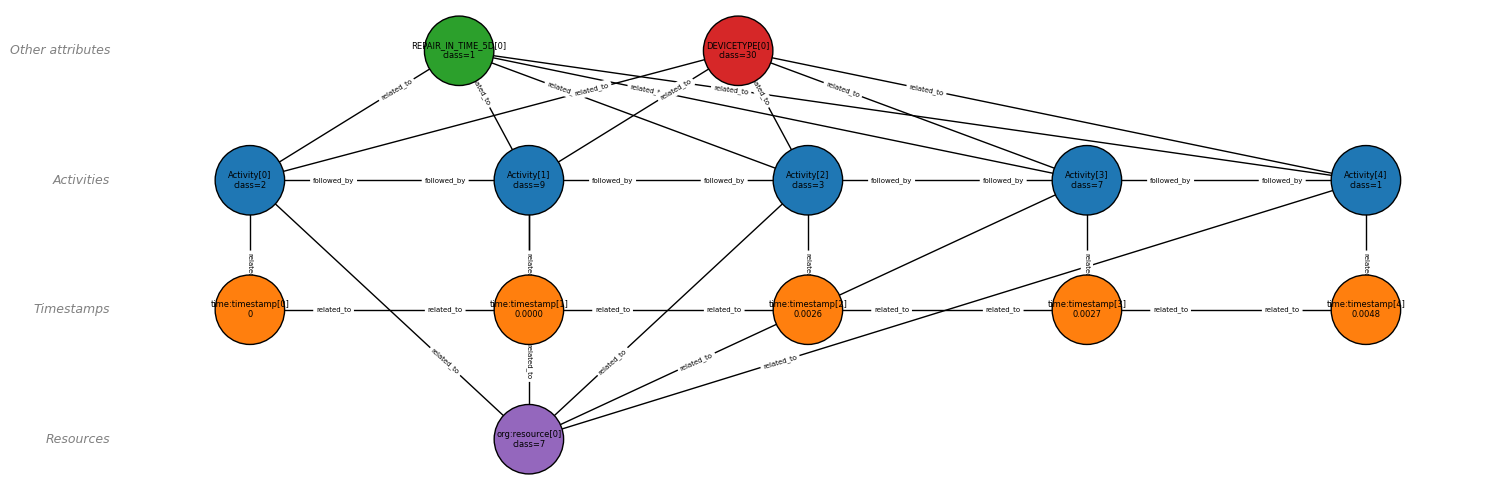

In [121]:
pred, gt = inference_single(net, g, t)

In [ ]:
"""
def test_hgnn(net, output_cat, output_real):

    # Assign loss functions to the categories
    losses = {}
    for k in output_cat:
        losses[k] = nn.CrossEntropyLoss()
    for k in output_real:
        losses[k] = nn.L1Loss()

    # Empty dictionaries to store tensors
    predictions_categorical = {k: [] for k in output_cat}
    target_categorical = {k: [] for k in output_cat}

    # avg_MAE = {k: [] for k in output_real}
    prediction_numerical = {k: [] for k in output_real}
    target_numerical = {k: [] for k in output_real}

    running_total_loss = []

    # Data loading (batches)
    test_loader = DataLoader([pair[0] for pair in X_TEST], 128, shuffle=False)
    
    # TESTING LOOP
    net.eval()
    with torch.no_grad():
        for i, x in enumerate(test_loader):
            x = x.to(device)
            labels = x.y

            # Forward pass
            outputs = net(x)

            # Compute loss
            losses_step = {k: losses[k](outputs[k], labels[k]) for k in losses}
            running_total_loss.append(sum(list(losses_step.values())))
        
            # INDENTING IT FORWARD BUT I DON'T KNOW IF THIS IS CORRECT
            for k in output_cat:
                predictions_categorical[k].append(
                        torch.argmax(torch.softmax(outputs[k], dim=1), 1)
                )
                target_categorical[k].append(labels[k])
            
            
            for k in output_real:
                prediction_numerical[k].append(
                    outputs[k]
                )
                target_numerical[k].append(
                    labels[k]
                )
    
    # Tensors merging
    for k in predictions_categorical:
        predictions_categorical[k] = torch.cat(predictions_categorical[k])
        target_categorical[k] = torch.cat(target_categorical[k])
            
    for k in prediction_numerical:
        prediction_numerical[k] = torch.cat(prediction_numerical[k])
        target_numerical[k] = torch.cat(target_numerical[k])
    
    # Metrics computation
    macro_f1s = {
        k : multiclass_f1_score(
            predictions_categorical[k],
            target_categorical[k].squeeze(),
            num_classes=output_cat[k],
            average='macro'
        )
        for k in output_cat
    }
        
    accuracy = {
            k: multiclass_accuracy(
                predictions_categorical[k],
                target_categorical[k].squeeze(),
                num_classes=output_cat[k],
            )
            for k in output_cat
        }
        
    MAE = {
        k: l1_loss(prediction_numerical[k], target_numerical[k]).item()
        for k in output_real
    }
    
    # avg_MAE = {k: sum(avg_MAE[k]) / len(avg_MAE[k]) for k in avg_MAE}

    Average_total_loss = sum(running_total_loss) / len(running_total_loss)

    res = (
        {f"{k}_acc": accuracy[k].item() for k in accuracy}
        | {f"{k}_macroF1": macro_f1s[k].item() for k in macro_f1s}
        | {f"{k}_mae": avg_MAE[k] for k in avg_MAE}
        | {"AVG_total_loss": Average_total_loss.item()}
        | {f"MAE_{k}": MAE[k] for k in MAE}
    )

    print(res)

    return res
"""